In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_palette("deep")

In [3]:
df = pd.read_csv("preply_tutors_data/preply_tutors_english.csv")

df.head()

,tutor_id,name,profile_url,country,badge,image_url,online_status,price,lesson_duration,rating,reviews,students,lessons,teaches,speaks,desc_title,desc_body,is_professional,is_super_tutor
0,649034,Madalina C.,https://preply.com/en/tutor/649034,Romania,professional,https://avatars.preply.com/i/logos/i/logos/ava...,Online,$26,50-min lesson,5.0,23.0,19.0,4149.0,English,"English(Proficient),, Spanish(Upper-Intermedia...",Certified teacher with over 6 years of experie...,"My name is Madalina, I have a TEFL certificate...",True,False
1,1481882,Esther Christina W.,https://preply.com/en/tutor/1481882,Netherlands,professional,https://avatars.preply.com/i/logos/i/logos/ava...,Offline,$22,50-min lesson,5.0,28.0,27.0,3525.0,English,English(Proficient),Certified teacher and absolute nerd with exper...,I love words and I love helping others find ou...,True,False
2,4807281,Sara J.,https://preply.com/en/tutor/4807281,Denmark,NaN,https://avatars.preply.com/i/logos/i/logos/ava...,Online,$25,50-min lesson,5.0,4.0,6.0,161.0,English,"English(Proficient),, Spanish(Upper-Intermedia...",Friendly English lessons to build confidence a...,Hi! 👋My name is Sara and I'm from Denmark. I c...,False,False
3,3031867,Petar D.,https://preply.com/en/tutor/3031867,North Macedonia,professional,https://avatars.preply.com/i/logos/i/logos/ava...,Online,$15,50-min lesson,5.0,22.0,9.0,1302.0,English,"English(Proficient),, Macedonian(Native) +4 more",Professional TEFL level 5 certified English tutor,I am a self-employed English translator and ed...,True,False
4,115540,Nastia P.,https://preply.com/en/tutor/115540,Israel,super tutor,https://avatars.preply.com/i/logos/i/logos/839...,Offline,$35,50-min lesson,5.0,19.0,15.0,2410.0,English,"English(Proficient),, Russian(Native) +1 more",Certified tutor with 8 years of experience. Le...,Hello everyone! I'm an experienced English tea...,False,True


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38950 entries, 0 to 38949
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tutor_id         38950 non-null  int64  
 1   name             38950 non-null  str    
 2   profile_url      38950 non-null  str    
 3   country          38950 non-null  str    
 4   badge            18467 non-null  str    
 5   image_url        38950 non-null  str    
 6   online_status    38950 non-null  str    
 7   price            38950 non-null  str    
 8   lesson_duration  38950 non-null  str    
 9   rating           22474 non-null  float64
 10  reviews          22474 non-null  float64
 11  students         22687 non-null  float64
 12  lessons          27903 non-null  float64
 13  teaches          38950 non-null  str    
 14  speaks           38950 non-null  str    
 15  desc_title       38950 non-null  str    
 16  desc_body        38950 non-null  str    
 17  is_professional  38950 

In [5]:
df["price"] = df["price"].replace("[\$,]", "", regex=True).astype(float)

df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

df["reviews"] = pd.to_numeric(df["reviews"], errors="coerce")

df["students"] = pd.to_numeric(df["students"], errors="coerce")

df["lessons"] = pd.to_numeric(df["lessons"], errors="coerce")

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
C:\Users\shehe\AppData\Local\Temp\ipykernel_34312\205028548.py:1: SyntaxWarning: invalid escape sequence '\$'
  df["price"] = df["price"].replace("[\$,]", "", regex=True).astype(float)


In [6]:
df.fillna({
    "rating":0,
    "reviews":0,
    "students":0,
    "lessons":0
}, inplace=True)

,tutor_id,name,profile_url,country,badge,image_url,online_status,price,lesson_duration,rating,reviews,students,lessons,teaches,speaks,desc_title,desc_body,is_professional,is_super_tutor
0,649034,Madalina C.,https://preply.com/en/tutor/649034,Romania,professional,https://avatars.preply.com/i/logos/i/logos/ava...,Online,26.0,50-min lesson,5.0,23.0,19.0,4149.0,English,"English(Proficient),, Spanish(Upper-Intermedia...",Certified teacher with over 6 years of experie...,"My name is Madalina, I have a TEFL certificate...",True,False
1,1481882,Esther Christina W.,https://preply.com/en/tutor/1481882,Netherlands,professional,https://avatars.preply.com/i/logos/i/logos/ava...,Offline,22.0,50-min lesson,5.0,28.0,27.0,3525.0,English,English(Proficient),Certified teacher and absolute nerd with exper...,I love words and I love helping others find ou...,True,False
2,4807281,Sara J.,https://preply.com/en/tutor/4807281,Denmark,NaN,https://avatars.preply.com/i/logos/i/logos/ava...,Online,25.0,50-min lesson,5.0,4.0,6.0,161.0,English,"English(Proficient),, Spanish(Upper-Intermedia...",Friendly English lessons to build confidence a...,Hi! 👋My name is Sara and I'm from Denmark. I c...,False,False
3,3031867,Petar D.,https://preply.com/en/tutor/3031867,North Macedonia,professional,https://avatars.preply.com/i/logos/i/logos/ava...,Online,15.0,50-min lesson,5.0,22.0,9.0,1302.0,English,"English(Proficient),, Macedonian(Native) +4 more",Professional TEFL level 5 certified English tutor,I am a self-employed English translator and ed...,True,False
4,115540,Nastia P.,https://preply.com/en/tutor/115540,Israel,super tutor,https://avatars.preply.com/i/logos/i/logos/839...,Offline,35.0,50-min lesson,5.0,19.0,15.0,2410.0,English,"English(Proficient),, Russian(Native) +1 more",Certified tutor with 8 years of experience. Le...,Hello everyone! I'm an experienced English tea...,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38945,6652464,Isa S.,https://preply.com/en/tutor/6652464,Brazil,professional,https://avatars.preply.com/i/logos/i/logos/ava...,Offline,30.0,50-min lesson,5.0,17.0,21.0,651.0,English,"English(Proficient),, Portuguese(Native) +3 more",English Teacher with 10+ Years of Experience |...,"Hello and welcome!I'm Isa, a teacher with 10 y...",True,False
38946,2676343,Matthew Erim M.,https://preply.com/en/tutor/2676343,Türkiye,super tutor,https://avatars.preply.com/i/logos/i/logos/ava...,Offline,30.0,50-min lesson,5.0,5.0,5.0,556.0,English,"English(Proficient),, Turkish(Native)",Bilingual English Teacher with ELT diploma and...,"Hello, my name is Matthew and I live in Istanb...",False,True
38947,7141922,Nicole P.,https://preply.com/en/tutor/7141922,Brazil,NaN,https://avatars.preply.com/i/logos/i/logos/ava...,Offline,10.0,50-min lesson,0.0,0.0,3.0,15.0,English,"English(Proficient),, Portuguese(Native)",English Teacher With Adaptive and Goal-Oriente...,"Hello there!I'm teacher Nic, a Brazilian educa...",False,False
38948,1518494,Bruna S.,https://preply.com/en/tutor/1518494,Brazil,professional,https://avatars.preply.com/i/logos/i/logos/ava...,Offline,13.0,50-min lesson,5.0,49.0,43.0,4570.0,English,"English(Proficient),, Portuguese(Native)",Certified English teacher with 11 years of exp...,"Hi, my name is Bruna! I have been an English t...",True,False


In [7]:
print("Total tutors:", len(df))

print("Professional tutors:", df["is_professional"].sum())

print("Super tutors:", df["is_super_tutor"].sum())

print("Average price:", df["price"].mean())

print("Median price:", df["price"].median())

Total tutors: 38950
Professional tutors: 17044
Super tutors: 1423
Average price: 14.322541720154044
Median price: 11.0


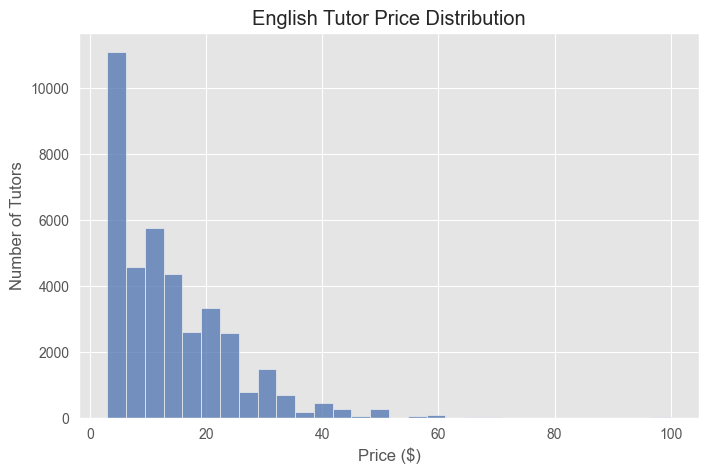

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=30)

plt.title("English Tutor Price Distribution")

plt.xlabel("Price ($)")

plt.ylabel("Number of Tutors")

plt.show()

In [9]:
df["price"].describe()

count    38950.000000
mean        14.322542
std         11.273061
min          3.000000
25%          6.000000
50%         11.000000
75%         20.000000
max        100.000000
Name: price, dtype: float64

In [10]:
badge_analysis = df.groupby(["is_professional","is_super_tutor"])["price"].mean()

badge_analysis

is_professional  is_super_tutor
False            False             12.802275
                 True              20.250176
True             False             15.654659
Name: price, dtype: float64

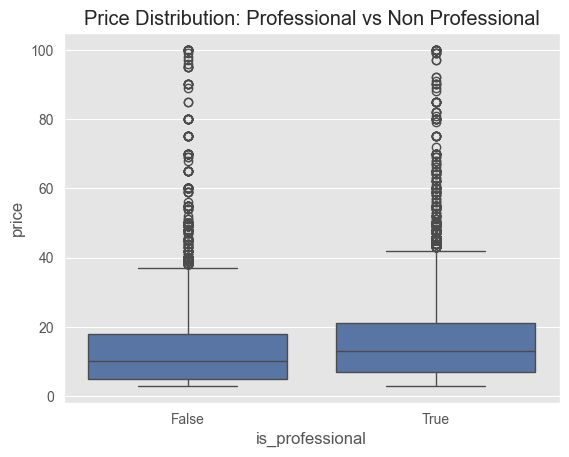

In [11]:
sns.boxplot(data=df, x="is_professional", y="price")

plt.title("Price Distribution: Professional vs Non Professional")

plt.show()


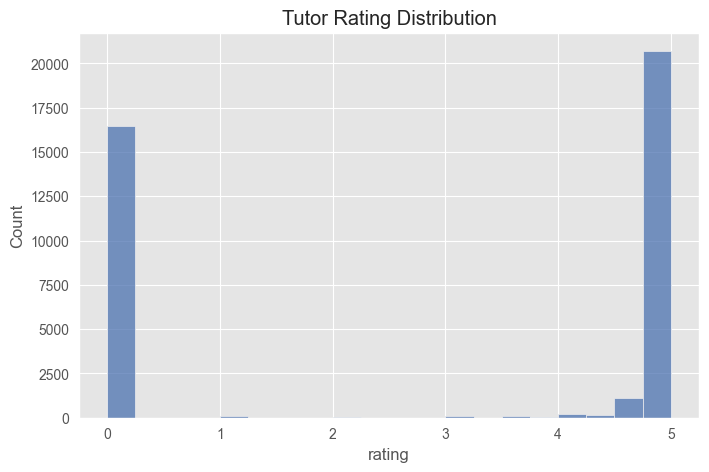

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["rating"], bins=20)

plt.title("Tutor Rating Distribution")

plt.show()

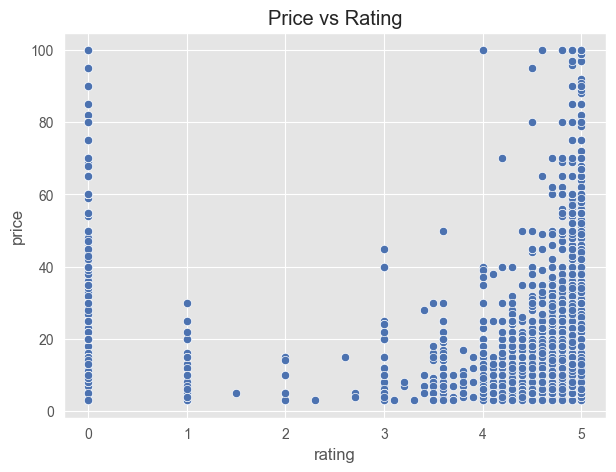

In [13]:
plt.figure(figsize=(7,5))

sns.scatterplot(data=df, x="rating", y="price")

plt.title("Price vs Rating")

plt.show()

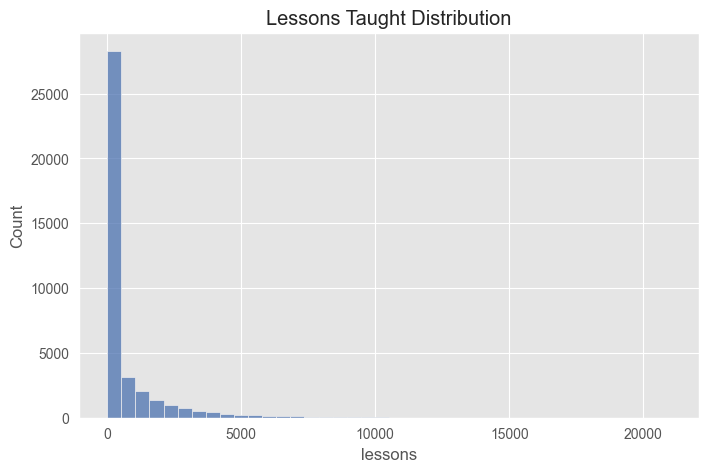

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df["lessons"], bins=40)

plt.title("Lessons Taught Distribution")

plt.show()

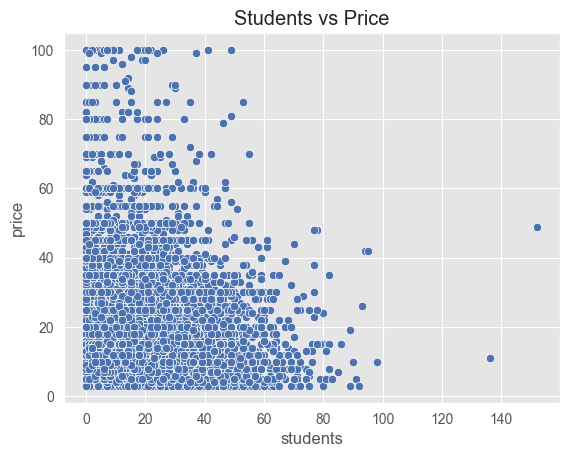

In [15]:
sns.scatterplot(data=df, x="students", y="price")

plt.title("Students vs Price")

plt.show()

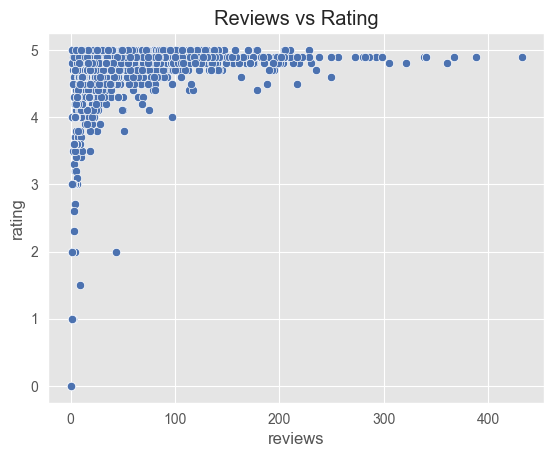

In [16]:
sns.scatterplot(data=df, x="reviews", y="rating")

plt.title("Reviews vs Rating")

plt.show()

In [17]:
top_countries = df["country"].value_counts().head(10)

top_countries

country
South Africa                7097
United States of America    4765
Philippines                 4133
United Kingdom              3985
Nigeria                     2080
Cameroon                    1723
Ukraine                     1177
Canada                       964
India                        837
Brazil                       763
Name: count, dtype: int64

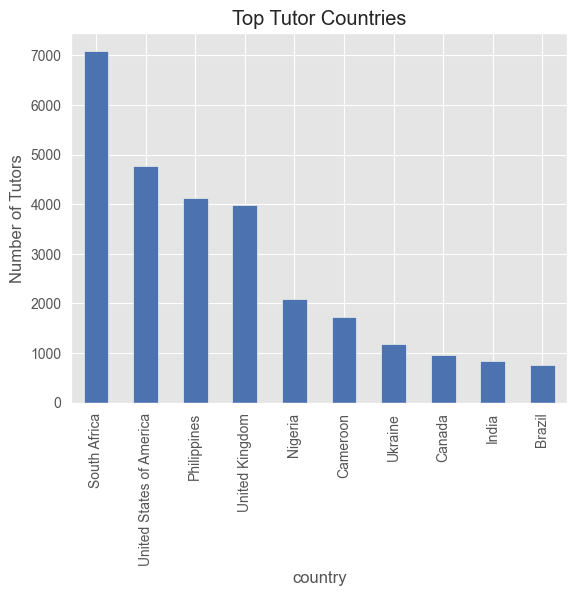

In [18]:
top_countries.plot(kind="bar")

plt.title("Top Tutor Countries")

plt.ylabel("Number of Tutors")

plt.show()

In [19]:
df.groupby("is_professional")[["price","rating","lessons","students"]].mean()

,price,rating,lessons,students
is_professional,,,,
False,13.286086,2.319241,500.72697,4.126267
True,15.654659,3.502411,933.74912,9.965149


In [20]:
df.groupby("is_super_tutor")[["price","rating","lessons","students"]].mean()

,price,rating,lessons,students
is_super_tutor,,,,
False,14.097770,2.757913,642.557465,6.358142
True,20.250176,4.922136,1946.936753,15.203092


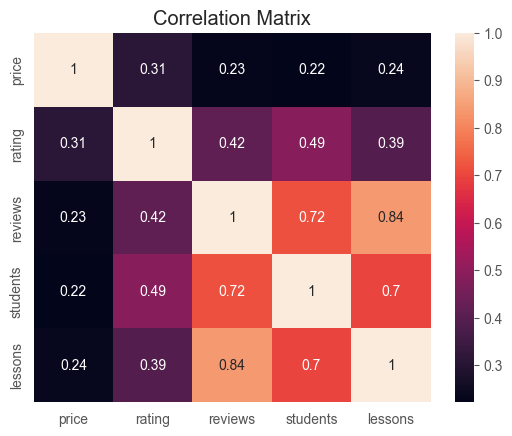

In [21]:
corr = df[["price","rating","reviews","students","lessons"]].corr()

sns.heatmap(corr, annot=True)

plt.title("Correlation Matrix")

plt.show()

In [22]:
df.sort_values("price", ascending=False).head(20)

,tutor_id,name,profile_url,country,badge,image_url,online_status,price,lesson_duration,rating,reviews,students,lessons,teaches,speaks,desc_title,desc_body,is_professional,is_super_tutor
9884,891898,Faith D.,https://preply.com/en/tutor/891898,Nigeria,professional,https://avatars.preply.com/i/logos/i/logos/ava...,Offline,100.0,50-min lesson,5.0,7.0,2.0,376.0,English,"English(Native),, Russian(Beginner) +2 more",Become proficient in your English communicatio...,"Hello! I am Faith, I hold a TEFL/TESOL, a Degr...",True,False
1487,5581611,Alen B.,https://preply.com/en/tutor/5581611,North Macedonia,NaN,https://avatars.preply.com/i/logos/i/logos/ava...,Offline,100.0,50-min lesson,0.0,0.0,2.0,0.0,English,"English(Proficient),, Turkish(Beginner) +4 more",🌟 Boost Your English Skills with a Certified T...,"Hello! My name is Alen, and I am a certified T...",False,False
37675,310367,Kawana G.,https://preply.com/en/tutor/310367,United States of America,professional,https://avatars.preply.com/i/logos/i/logos/ava...,Online,100.0,50-min lesson,5.0,43.0,49.0,2966.0,English,"English(Native),, Spanish(Intermediate)","Speak, Succeed, Excel: Dynamic Results Driven ...","Hello,I'm a TEFL-certified American English te...",True,False
3247,7501297,Anatoly G.,https://preply.com/en/tutor/7501297,United Kingdom,professional,https://avatars.preply.com/i/logos/i/logos/ava...,Offline,100.0,50-min lesson,5.0,1.0,8.0,1.0,English,"English(Native),, Russian(Native)",Business English for IT Professionals | Meetin...,Business English for IT Professionals | Meetin...,True,False
32381,93012,Tyler S.,https://preply.com/en/tutor/93012,United States of America,professional,https://avatars.preply.com/i/logos/i/logos/689...,Offline,100.0,50-min lesson,5.0,17.0,41.0,1439.0,English,"English(Native),, Italian(Beginner) +6 more",English Coach 🌟Accent & Fluency Coach in Los A...,🧠 Neurolinguist 🌟Accent & Fluency Coach in Los...,True,False
3234,1253266,Predz W.,https://preply.com/en/tutor/1253266,Australia,NaN,https://avatars.preply.com/i/logos/i/logos/ava...,Offline,100.0,50-min lesson,4.9,54.0,21.0,716.0,English,"English(Native),, Korean(Advanced)",ESL Certified Premium English MasterClass + Lo...,Welcome to my Premium Master Class where you w...,False,False
32257,756331,Kevin C.,https://preply.com/en/tutor/756331,United Kingdom,NaN,https://avatars.preply.com/i/logos/i/logos/ava...,Offline,100.0,50-min lesson,5.0,8.0,2.0,709.0,English,"English(Native),, German(Proficient) +1 more",CELTA qualified English teacher with twenty-fo...,**PLEASE NOTE BEFORE READING MY PROFILE THAT I...,False,False
32979,4050707,Sandrisha G.,https://preply.com/en/tutor/4050707,South Africa,professional,https://avatars.preply.com/i/logos/i/logos/ava...,Online,100.0,50-min lesson,4.6,8.0,9.0,1316.0,English,"English(Native),, Afrikaans(Native)","Qualified,patient English lecturer with 7 year...",Hello 👋! My name is Sandrisha (Sandy)🌈 and I a...,True,False
5701,364489,Peter B.,https://preply.com/en/tutor/364489,United States of America,NaN,https://avatars.preply.com/i/logos/i/logos/ava...,Online,100.0,50-min lesson,4.9,32.0,11.0,2861.0,English,English(Native),Building confidence and flexibility both in yo...,Hi! I'm an American TEFL & TESOL trained tuto...,False,False
2642,7118043,Lim A.,https://preply.com/en/tutor/7118043,Malaysia,NaN,https://avatars.preply.com/i/logos/i/logos/ava...,Offline,100.0,50-min lesson,0.0,0.0,10.0,0.0,English,"English(Proficient),, Indonesian(Intermediate)...",Passionate English Teacher \nPersonalized Less...,"Hello, I am Lim, a dedicated English teacher w...",False,False


In [23]:
df.sort_values("lessons", ascending=False).head(20)

,tutor_id,name,profile_url,country,badge,image_url,online_status,price,lesson_duration,rating,reviews,students,lessons,teaches,speaks,desc_title,desc_body,is_professional,is_super_tutor
553,20,Yuri S.,https://preply.com/en/tutor/20,Ukraine,professional,https://avatars.preply.com/i/logos/i/logos/ava...,Offline,60.0,50-min lesson,4.9,280.0,47.0,21025.0,English,"English(Proficient),, Ukrainian(Native) +1 more",NeuroMethod Expert | 20+ Years Helping Adults ...,"Hi, I’m Yuri. I’ve been teaching English for o...",True,False
2804,197633,Arman A.,https://preply.com/en/tutor/197633,United Kingdom,professional,https://avatars.preply.com/i/logos/i/logos/ava...,Online,49.0,50-min lesson,4.9,432.0,152.0,20587.0,English,English(Native),FORMER IELTS EXAMINER and CAE instructor. Conv...,PLEASE SEND ME A SHORT MESSAGE BEFORE BOOKING ...,True,False
654,3235,Igor L.,https://preply.com/en/tutor/3235,Ukraine,professional,https://avatars.preply.com/i/logos/i/logos/119...,Online,25.0,50-min lesson,4.8,305.0,43.0,20208.0,English,"English(Proficient),, German(Advanced) +2 more",Certified English tutor with 25 years experie...,Hello and thank you for visiting my my page....,True,False
26380,18692,Mark T.,https://preply.com/en/tutor/18692,United States of America,professional,https://avatars.preply.com/i/logos/i/logos/ava...,Online,44.0,50-min lesson,4.5,217.0,70.0,19183.0,English,"English(Native),, Spanish(Proficient) +4 more",Advanced TESOL Instructor with 12 years Teachi...,"My over 150 reviews speak for themselves, but ...",True,False
29975,6086,Roman K.,https://preply.com/en/tutor/6086,Ukraine,professional,https://avatars.preply.com/i/logos/i/logos/243...,Online,12.0,50-min lesson,4.8,63.0,37.0,18113.0,English,"English(Proficient),, Ukrainian(Native) +1 more",Certified English teacher with twelve years of...,"If you have a desire to learn and develop, I w...",True,False
24962,744097,Dhanasagree M.,https://preply.com/en/tutor/744097,South Africa,professional,https://avatars.preply.com/i/logos/i/logos/ava...,Online,7.0,50-min lesson,4.8,117.0,40.0,17920.0,English,"English(Native),, Afrikaans(Native)",🌈ENGLISH CONVERSATION & CONFIDENCE COACH FOR A...,"👋 Hello and welcome! I’m Dhana (aka Annie), a ...",True,False
3918,296366,Ivy C.,https://preply.com/en/tutor/296366,Philippines,NaN,https://avatars.preply.com/i/logos/i/logos/ava...,Online,5.0,50-min lesson,4.8,115.0,91.0,17626.0,English,"English(Native),, Cebuano(Native) +1 more",🌍 PROFESSIONAL LICENSED TEACHER and CERTIFIED...,"Hello, dear students!My name is Teacher Ivy, a...",False,False
32517,993962,Elchin K.,https://preply.com/en/tutor/993962,Azerbaijan,professional,https://avatars.preply.com/i/logos/i/logos/ava...,Offline,15.0,50-min lesson,4.9,132.0,78.0,17357.0,English,"English(Proficient),, Azerbaijani(Upper-Interm...","TESOL certified, specializing in improving the...","Hi there. During my classes, you are going to ...",True,False
31964,993962,Elchin K.,https://preply.com/en/tutor/993962,Azerbaijan,professional,https://avatars.preply.com/i/logos/i/logos/ava...,Online,15.0,50-min lesson,4.9,132.0,78.0,17348.0,English,"English(Proficient),, Azerbaijani(Upper-Interm...","TESOL certified, specializing in improving the...","Hi there. During my classes, you are going to ...",True,False
32675,773243,Ali A.,https://preply.com/en/tutor/773243,Pakistan,professional,https://avatars.preply.com/i/logos/i/logos/ava...,Online,42.0,50-min lesson,4.9,340.0,95.0,17309.0,English,English(Native),"✅ ⭐ Certified IELTS, TOEFL, PTE, FCE, CAE, CPE...","Hi! I’m Ali, a certified English teacher with ...",True,False


In [25]:
summary = df.describe()

summary.to_csv("preply_tutors_data/english_analysis_summary_preply.csv")